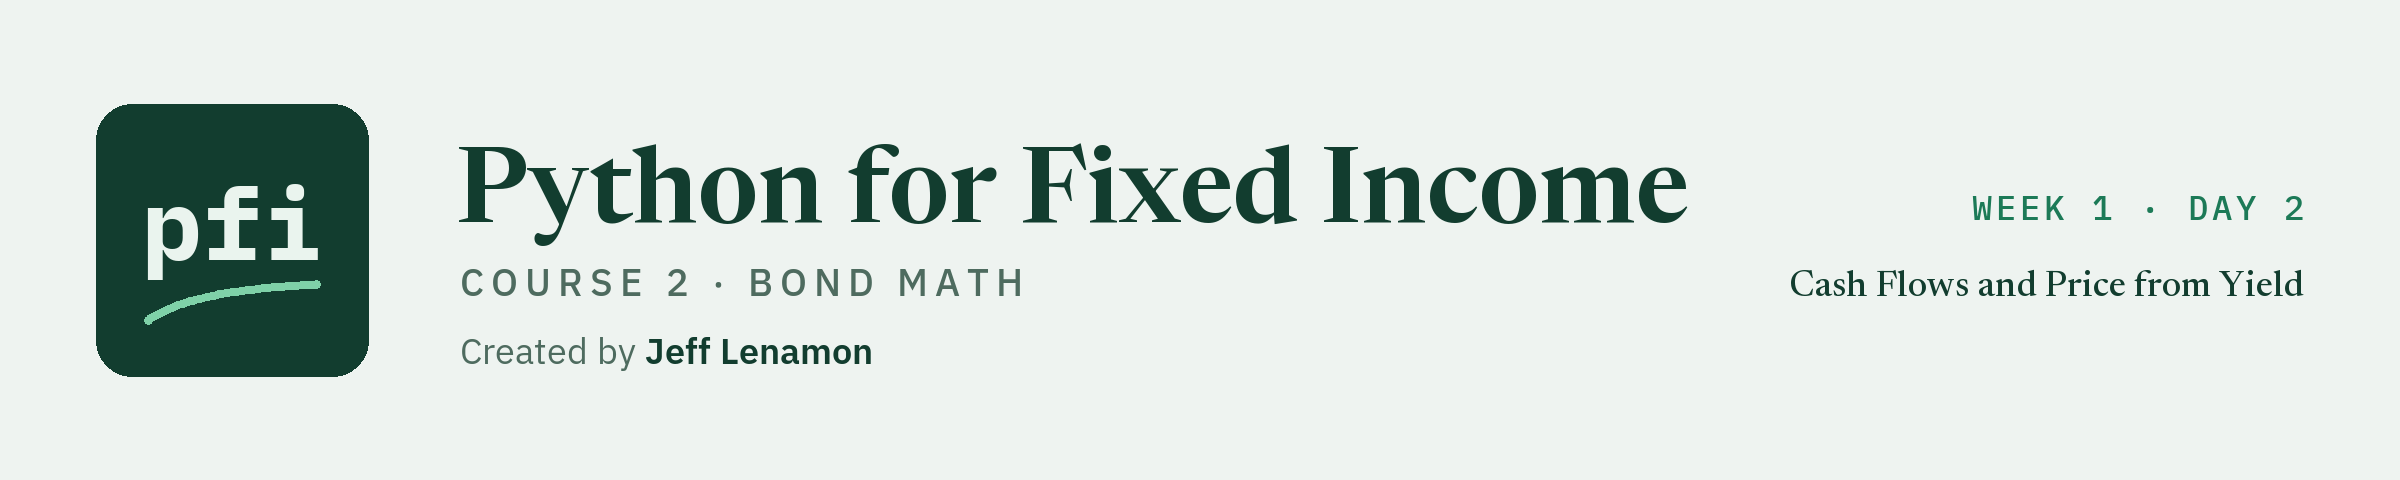

# Cash Flows and Price from Yield

Week 1, Day 2. A bond is a list of cash flows, and on a coupon date its price is the sum of their present values: two more functions for your module, tested against Excel's PV and PRICE.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course2_bond_math/week1/day2/02_cash_flows_and_price_from_yield.ipynb)

Yesterday ended with one number for each of the desk's four new bonds: what its redemption of 100 is worth today. Quorvane Energy's 100, due on 30 September 2031, is worth 76.6118 today at its yield of 5.40 percent, compounded twice a year.

That is not Quorvane's price. A holder also receives a coupon every six months until then, ten of them, and each is worth something today too. Today a bond becomes what it really is: **a list of cash flows, each with its own discount factor.** Its price is the sum of their present values.

Today you will:

1. List the cash flows of a bullet bond: every coupon, and the 100 at the end.
2. Discount each one and add them up: the price on a coupon date.
3. Add `cash_flows` and `price_from_yield` to your module, docstring first.
4. Test them against Excel's PV and PRICE with pytest.
5. See why clean and dirty price are the same today, and why that changes in week 2.
6. Read today's changes with `git diff`, commit them, and see the history with `git log`.

The bonds still settle on Wednesday 30 September 2026, a coupon date, so every bond has a whole number of half-years left. Excel stays the answer key: the reference files hold its price for each of the four bonds.

The issuers are invented. Every number here describes the data, and nothing says a bond or an issuer is good or bad.

The setup cell is the same as yesterday's. Then, because this is day 2, the next cell writes `bondmath.py` and `test_bondmath.py` as they stood at the end of day 1. If you skipped day 1, or the work folder is new, you still start from the right place.

Q. Set up today's work folder and copy the Excel reference files into it.

In [1]:
# modules that come with Python: folders and files, the temp folder, running programs, reloading a module
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# pytest runs the tests. A Colab runtime may not have it.
try:
    import pytest
except ImportError:
    raise RuntimeError("pytest is not installed. Run  !pip install pytest  in a new cell, then run this cell again.") from None

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "bondmath_excel_reference.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course2_02_"))
os.chdir(work)

# 3. copy the two Excel reference files into the work folder
for name in ["bondmath_excel_reference.csv", "bondmath_excel_reference_tvm.csv"]:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Reference files copied from: {'GitHub' if on_github else 'the data folder of the course repo'}")
print(f"pytest version: {pytest.__version__}")

Work folder: pfi_course2_02_pdadgcaz, in your temp folder
Reference files copied from: the data folder of the course repo
pytest version: 9.1.1


Q. Write `bondmath.py` and `test_bondmath.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods

Writing bondmath.py


In [3]:
%%writefile test_bondmath.py
"""Tests for bondmath.py.

Every expected value comes from Excel: the two reference CSV files in this folder, or a small hand
table whose values those files confirm. Run from this folder with:  python -m pytest
"""
import csv
import math  # used from week 3
from datetime import date  # used from week 2
from pathlib import Path

import pytest

import bondmath

# the reference files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_rows(file_name: str) -> list[dict]:
    """Read a reference CSV from this folder: one dict per row, every value a string."""
    with open(HERE / file_name, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


TVM = read_rows("bondmath_excel_reference_tvm.csv")


def tvm_rows(function: str) -> list[dict]:
    """The week 1 reference rows for one Excel function, for example "FV"."""
    rows = [row for row in TVM if row["function"] == function]
    assert rows, f"no {function} rows in the reference file"
    return rows


def test_future_value_matches_excel_fv():
    for row in tvm_rows("FV"):
        # the inputs, in course units
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.future_value(amount, rate_pct, years, frequency)
        # Excel's FV, with the amount entered as -amount, is positive
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_matches_excel_pv():
    for row in tvm_rows("PV"):
        amount, rate_pct = float(row["amount"]), float(row["rate_pct"])
        years, frequency = float(row["years"]), int(row["frequency"])
        result = bondmath.present_value(amount, rate_pct, years, frequency)
        # Excel's PV of a positive amount is negative (money paid now), so compare with minus the Excel value
        assert result == pytest.approx(-float(row["excel_value"]), abs=1e-6), row["case_id"]


def test_present_value_undoes_future_value():
    for frequency in (1, 2, 4):
        # grow 100 for 3 years at 5 percent, then discount it back
        grown = bondmath.future_value(100, 5.0, 3, frequency)
        assert bondmath.present_value(grown, 5.0, 3, frequency) == pytest.approx(100, abs=1e-9)

Writing test_bondmath.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)

# the functions defined in the module itself, not the ones it imports
functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value']


* `Writing bondmath.py` and `Writing test_bondmath.py`: the two files exactly as day 1 left them, with `future_value` and `present_value` and their three tests.
* The import cell lists the two functions. By the end of today there will be four.

Your own `my_bondmath` folder already has yesterday's commit. This work folder is new, so record its starting point in Git now. Then, at the end of the day, Git can show exactly what today added. The Git commands are explained in day 1 and in the Save the Day with Git section below.

Q. Make the work folder a repository and commit the start-of-day files.

In [5]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [6]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course2_02_pdadgcaz and nowhere else


In [7]:
# choose the two files, commit them quietly, and show the history
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -q -m "Start of day 2: bondmath.py and test_bondmath.py as day 1 left them"
!git -C "{work}" log --oneline

98f12b8 Start of day 2: bondmath.py and test_bondmath.py as day 1 left them


* One commit, with a hash that changes on every run. `-q` keeps the commit quiet; `git log --oneline` shows it on one line.

Q. Type in the four bonds.

In [8]:
bonds = pd.DataFrame({
    "cusip": ['99001BZA7', '99002CZA4', '99003DZA1', '99004EZA8'],
    "issuer": ['Quorvane Energy', 'Dunmarrow Rail', 'Pellwick Paper', 'Halvering Foods'],
    "ticker": ['QVNE', 'DNMR', 'PLWK', 'HLVF'],
    "rating": ['BBB', 'BB+', 'A-', 'B+'],
    "coupon_pct": [5.25, 6.125, 4.75, 7.5],
    "maturity": ['2031-09-30', '2033-09-30', '2029-09-30', '2036-09-30'],
    "years": [5, 7, 3, 10],
    "yield_pct": [5.4, 6.125, 4.6, 7.7],
})

bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99001BZA7,Quorvane Energy,QVNE,BBB,5.250,2031-09-30,5,5.400
1,99002CZA4,Dunmarrow Rail,DNMR,BB+,6.125,2033-09-30,7,6.125
2,99003DZA1,Pellwick Paper,PLWK,A-,4.750,2029-09-30,3,4.600
3,99004EZA8,Halvering Foods,HLVF,B+,7.500,2036-09-30,10,7.700


* The same four bonds as yesterday: Pellwick in 3 years, Quorvane in 5, Dunmarrow in 7, and Halvering in 10, every one settling on a coupon date.

## 2.1 The Cash Flows of a Bullet Bond

A **bullet bond** pays a fixed coupon at regular intervals and repays all of its face in one piece at maturity. Every bond in this course is one. Its cash flows follow from three numbers: the annual coupon, the years left, and the number of coupons a year.

Quorvane's coupon is 5.25 percent of face a year, paid twice a year. Each payment is half of that: 2.625 per 100 of face. The last payment, at maturity, also returns the 100.

Q. List every cash flow Quorvane pays from today to maturity, with its time in years.

In [9]:
quorvane = bonds.iloc[0]

# two coupons a year: the number of payments, and the size of each coupon per 100 of face
frequency = 2
periods = frequency * quorvane["years"]
coupon = quorvane["coupon_pct"] / frequency

rows = []
for k in range(1, periods + 1):
    # payment k arrives k half-years from today
    time_years = k / frequency
    # the last payment also returns the face of 100
    amount = coupon + 100 if k == periods else coupon
    rows.append({"payment": k, "time_years": time_years, "cash_flow": amount})

quorvane_flows = pd.DataFrame(rows)
quorvane_flows

,payment,time_years,cash_flow
0,1,0.5,2.625
1,2,1.0,2.625
2,3,1.5,2.625
3,4,2.0,2.625
4,5,2.5,2.625
5,6,3.0,2.625
6,7,3.5,2.625
7,8,4.0,2.625
8,9,4.5,2.625
9,10,5.0,102.625


* 10 payments, one every half-year. Nine coupons of 2.625, then 102.625 at 5 years: the last coupon and the face together.
* The coupon is the annual rate divided by the frequency. A 5.25 percent coupon paid twice a year is 2.625 per payment, not 5.25. Forget the division and every coupon is twice its size: today's AI check is exactly that.

Q. How much cash does Quorvane pay in all, per 100 of face?

In [10]:
total_cash = quorvane_flows["cash_flow"].sum()
total_coupons = total_cash - 100

print(f"Total cash: {total_cash:.2f} per 100 of face: {total_coupons:.2f} of coupons and 100.00 of face")

Total cash: 126.25 per 100 of face: 26.25 of coupons and 100.00 of face


* 126.25 per 100 of face over five years. Nobody pays 126.25 for it today, because most of that cash arrives years from now. Section 2.2 puts a value today on each piece.

Q. How many payments does each bond make, how large is each coupon, and how much cash does it pay in all?

In [11]:
# the same three numbers for every bond at once, as columns
bonds["payments"] = frequency * bonds["years"]
bonds["coupon_per_payment"] = bonds["coupon_pct"] / frequency
bonds["total_cash"] = bonds["payments"] * bonds["coupon_per_payment"] + 100

bonds[["issuer", "coupon_pct", "years", "payments", "coupon_per_payment", "total_cash"]]

,issuer,coupon_pct,years,payments,coupon_per_payment,total_cash
0,Quorvane Energy,5.250,5,10,2.6250,126.250
1,Dunmarrow Rail,6.125,7,14,3.0625,142.875
2,Pellwick Paper,4.750,3,6,2.3750,114.250
3,Halvering Foods,7.500,10,20,3.7500,175.000


* Halvering pays the most cash, 175.00 per 100 over ten years, and Pellwick the least, 114.25 over three. More cash in total does not mean a higher price: it is spread over more years, and the later it comes the less it is worth today.

## 2.2 Price as the Sum of Discounted Cash Flows

On day 1 you discounted one payment: Quorvane's 100 at 5 years. A coupon is a payment too, just smaller and sooner. Each cash flow gets the discount factor for its own time, at the bond's yield, and **the price is the sum of the present values.** On a coupon date that is the whole method.

Q. Discount each of Quorvane's cash flows at its yield of 5.40 percent, compounded twice a year.

In [12]:
# the yield for one half-year, as a decimal
period_yield = quorvane["yield_pct"] / 100 / frequency

# each cash flow gets the discount factor for its own number of half-years
quorvane_flows["discount_factor"] = 1 / (1 + period_yield) ** quorvane_flows["payment"]
quorvane_flows["present_value"] = quorvane_flows["cash_flow"] * quorvane_flows["discount_factor"]

quorvane_flows.round(6)

,payment,time_years,cash_flow,discount_factor,present_value
0,1,0.5,2.625,0.973710,2.555988
1,2,1.0,2.625,0.948111,2.488791
2,3,1.5,2.625,0.923185,2.423360
3,4,2.0,2.625,0.898914,2.359650
4,5,2.5,2.625,0.875282,2.297614
5,6,3.0,2.625,0.852270,2.237209
6,7,3.5,2.625,0.829864,2.178393
7,8,4.0,2.625,0.808047,2.121123
8,9,4.5,2.625,0.786803,2.065358
9,10,5.0,102.625,0.766118,78.622841


* The discount factor falls with every half-year: 0.973710 for the first coupon, 0.766118 for the last payment. The last factor is the one from day 1.
* Each coupon of 2.625 is worth a little less than the one before it. The first is worth 2.555988 today, the ninth 2.065358.

Q. Add up the present values. What is Quorvane's price?

In [13]:
price = quorvane_flows["present_value"].sum()

print(f"Quorvane's price at 5.40 percent: {price:.4f} per 100 of face")

Quorvane's price at 5.40 percent: 99.3503 per 100 of face


* 99.3503 per 100 of face. That is the price on 30 September 2026 at a yield of 5.40 percent: the amount which, invested at 5.40 percent compounded twice a year, would pay out exactly Quorvane's ten cash flows.

Q. How much of the price is the redemption, and how much is the coupons?

In [14]:
# the last payment holds the 100 of face; its present value is the redemption part
redemption_pv = 100 * quorvane_flows["discount_factor"].iloc[-1]
coupons_pv = price - redemption_pv

print(f"Redemption: {redemption_pv:.4f} per 100, {redemption_pv / price * 100:.1f} percent of the price")
print(f"Coupons:    {coupons_pv:.4f} per 100, {coupons_pv / price * 100:.1f} percent of the price")

Redemption: 76.6118 per 100, 77.1 percent of the price
Coupons:    22.7385 per 100, 22.9 percent of the price


* The redemption is worth 76.6118, day 1's number. The ten coupons add 22.7385. Together they make 99.3503.
* Yesterday's present value was one cash flow. Today's price is the same calculation, once for each cash flow.

Q. Price all four bonds the same way, each at its own yield.

In [15]:
prices = []
for bond in bonds.itertuples():
    period_yield = bond.yield_pct / 100 / frequency
    periods = frequency * bond.years
    price = 0.0
    for k in range(1, periods + 1):
        # a coupon every half-year, and the face with the last one
        amount = bond.coupon_pct / frequency + (100 if k == periods else 0)
        # discounted for k half-years
        price += amount / (1 + period_yield) ** k
    prices.append(price)

bonds["price"] = prices
bonds[["issuer", "coupon_pct", "yield_pct", "years", "price"]].round(4)

,issuer,coupon_pct,yield_pct,years,price
0,Quorvane Energy,5.250,5.400,5,99.3503
1,Dunmarrow Rail,6.125,6.125,7,100.0000
2,Pellwick Paper,4.750,4.600,3,100.4159
3,Halvering Foods,7.500,7.700,10,98.6227


* Pellwick prices at 100.4159, above 100: its coupon, 4.75 percent, is above its yield, 4.60 percent.
* Dunmarrow prices at 100.0000: its coupon and its yield are both 6.125 percent.
* Quorvane, 99.3503, and Halvering, 98.6227, price below 100: each coupon is below its yield.
* Above par, at par, and below par: day 3 is about why, and about how a price moves when the yield moves.

**Excel side by side.** Three ways to price Quorvane in a sheet, all tested in Excel:

* **A column of cash flows and NPV.** Type `=5.25/2` in B1 and fill it down to B9, and `=5.25/2+100` in B10. Then `=NPV(5.4/100/2,B1:B10)` returns 99.350327. NPV takes the rate per period and the list of cash flows, and discounts the first value by one full period, the second by two, and so on. On a coupon date that is exactly right: the first coupon is one half-year away.
* **Every cash flow discounted in its own cell.** Put the payment numbers 1 to 10 in A1:A10 beside the cash flows. Type `=B1/(1+5.4/100/2)^A1` in C1, fill it down to C10, and `=SUM(C1:C10)` returns 99.350327. This is the table above, cell for cell.
* **One formula.** `=-PV(5.4/100/2,2*5,5.25/2,100)` returns 99.35032727691537. PV's third argument is now the coupon each period, 5.25/2, and the fourth is the 100 at the end. As on day 1, PV comes back negative, and the minus in front makes it positive.

The three agree with each other, and with the sum above, to the twelfth decimal place.

## 2.3 `cash_flows` and `price_from_yield` into the Module

Two calculations from today belong in the module: listing the cash flows, and pricing from the yield. Docstring first, as on day 1: the units, the convention, and the Excel formula, before any code.

Q. Add `cash_flows` to the end of `bondmath.py`. Read the cell before you run it.

In [16]:
%%writefile -a bondmath.py


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows

Appending to bondmath.py


* `Appending to bondmath.py`. The function returns a list of pairs, `(time in years, cash flow)`, earliest first: a pair of values in round brackets is a **tuple**, Python's fixed-size group of values. The type hint `list[tuple[float, float]]` says exactly that.
* It stops on a frequency other than 1, 2, or 4, as `future_value` does.
* It stops too if the years do not make a whole number of coupon periods. Today's method only works on a coupon date, so 2.3 years at two coupons a year is refused rather than priced wrongly. The check allows a difference of 1e-9 because a float multiplication such as `2.3 * 2` is not always exact.
* The loop is the one from section 2.1, with the frequency as an argument.

Q. Add `price_from_yield`.

In [17]:
%%writefile -a bondmath.py


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price

Appending to bondmath.py


* `price_from_yield` does not list the cash flows itself: it calls `cash_flows`, so the coupon rule lives in one place.
* `time_years * frequency` turns a time in years back into a number of periods: 2.5 years at frequency 2 is 5 half-years.
* The docstring says the result is both the clean and the dirty price on a coupon date. Section 2.5 explains.

Q. Reload the module, so the notebook sees the two new functions.

In [18]:
# the file changed, so read it again
importlib.reload(bondmath)

functions = [name for name, obj in vars(bondmath).items() if callable(obj) and getattr(obj, "__module__", "") == "bondmath"]
print(f"bondmath functions: {functions}")

bondmath functions: ['future_value', 'present_value', 'cash_flows', 'price_from_yield']


* Four functions now, in the order they were written.

Q. Does `cash_flows` give the list built by hand in section 2.1?

In [19]:
flows = bondmath.cash_flows(5.25, 5)

# the first two and the last, as (time in years, cash flow per 100)
print(f"First two: {flows[:2]}")
print(f"Last:      {flows[-1]}")

# every pair must match the table from section 2.1
assert flows == list(zip(quorvane_flows["time_years"], quorvane_flows["cash_flow"]))
print(f"{len(flows)} cash flows, the same as the hand-built table")

First two: [(0.5, 2.625), (1.0, 2.625)]
Last:      (5.0, 102.625)
10 cash flows, the same as the hand-built table


* `(0.5, 2.625)` first and `(5.0, 102.625)` last, ten pairs in all, equal to the table pair for pair.
* `flows[:2]` is a slice and `flows[-1]` the last item, as with any list in Course 1.

Q. What happens for 2.3 years, which is not a whole number of half-years?

In [20]:
# try and except, from Course 1: catch the error and print its message
try:
    bondmath.cash_flows(5.25, 2.3)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: 2.3 years is not a whole number of periods at frequency 2


* The function refuses, and the message says why. A bond with 2.3 years left is between coupon dates, and pricing it needs the dates themselves: week 2.

Q. Price the four bonds with `price_from_yield`. Do they match section 2.2?

In [21]:
# one call for each bond, with its own coupon, yield, and years
bonds["price_from_module"] = [
    bondmath.price_from_yield(c, y, t) for c, y, t in zip(bonds["coupon_pct"], bonds["yield_pct"], bonds["years"])
]

# the module must agree with the loop in section 2.2
assert (bonds["price_from_module"] - bonds["price"]).abs().max() < 1e-9
bonds[["issuer", "coupon_pct", "yield_pct", "years", "price", "price_from_module"]].round(4)

,issuer,coupon_pct,yield_pct,years,price,price_from_module
0,Quorvane Energy,5.250,5.400,5,99.3503,99.3503
1,Dunmarrow Rail,6.125,6.125,7,100.0000,100.0000
2,Pellwick Paper,4.750,4.600,3,100.4159,100.4159
3,Halvering Foods,7.500,7.700,10,98.6227,98.6227


* The same four prices. The arguments go in the docstring's order: coupon, yield, years, and the frequency left at its default of 2.

Q. What does `price_from_yield` promise? Ask it.

In [22]:
help(bondmath.price_from_yield)

Help on function price_from_yield in module bondmath:

price_from_yield(
    coupon_pct: float,
    yield_pct: float,
    years: float,
    frequency: int = 2
) -> float
    Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)



* The units, the convention, the note about clean and dirty, and the Excel formula, which is the third route of section 2.2 with the bond's numbers in place of the names.

## 2.4 Tests

Three new tests: two for `cash_flows` and one for `price_from_yield`. As on day 1, the expected numbers come from Excel, or from a small case you can check by hand.

Q. Add the two tests for `cash_flows`. Read them first.

In [23]:
%%writefile -a test_bondmath.py


REFERENCE = read_rows("bondmath_excel_reference.csv")


def test_cash_flows_count_and_final_flow():
    flows = bondmath.cash_flows(6.0, 5, 2)
    # 5 years of half-year coupons is 10 cash flows
    assert len(flows) == 10
    # the first is a 3.00 coupon after half a year, the last is the coupon plus the face at 5 years
    assert flows[0] == pytest.approx((0.5, 3.0))
    assert flows[-1] == pytest.approx((5.0, 103.0))


def test_cash_flows_raises_on_part_periods():
    # 2.3 years is not a whole number of half years, so cash_flows must stop with a ValueError
    try:
        bondmath.cash_flows(6.0, 2.3, 2)
    except ValueError:
        return
    assert False, "cash_flows accepted 2.3 years at frequency 2"

Appending to test_bondmath.py


* `REFERENCE` reads the second reference file, `bondmath_excel_reference.csv`, with yesterday's `read_rows`. Today uses its coupon-date rows; week 2 uses all of it.
* `test_cash_flows_count_and_final_flow` checks a case you can do in your head: a 6 percent coupon for 5 years pays 10 times, 3.00 after half a year, and 103.00 at 5 years. `pytest.approx` compares the pairs number by number.
* `test_cash_flows_raises_on_part_periods` passes only if `cash_flows` refuses 2.3 years. If the call returns, the `return` inside `except` is never reached, and `assert False` fails the test with its message. Day 4 shows pytest's own way to write this.

Q. Add the test for `price_from_yield`.

In [24]:
%%writefile -a test_bondmath.py


def test_price_from_yield_matches_excel():
    # Excel's -PV with a coupon: a bond priced on a coupon date
    for row in tvm_rows("PV_BOND"):
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["rate_pct"]),
                                           float(row["years"]), int(row["frequency"]))
        assert result == pytest.approx(float(row["excel_value"]), abs=1e-6), row["case_id"]
    # Excel's PRICE on the rows that settle on a coupon date (no days accrued)
    coupon_date_rows = [row for row in REFERENCE if row["coupdaybs"] == "0"]
    assert coupon_date_rows, "no coupon-date rows in the reference file"
    for row in coupon_date_rows:
        frequency = int(row["frequency"])
        years = int(row["coupnum"]) / frequency
        result = bondmath.price_from_yield(float(row["coupon_pct"]), float(row["yield_pct"]), years, frequency)
        assert result == pytest.approx(float(row["price"]), abs=1e-6), row["case_id"]

Appending to test_bondmath.py


* The first loop checks every `PV_BOND` row of the week 1 file: Excel's `-PV` with a coupon, the third route of section 2.2. `rate_pct` there is the yield.
* The second loop checks Excel's `PRICE` on every row of the bond file whose settlement is a coupon date, the rows with no days accrued (`coupdaybs` is 0). On those rows the years left are the coupons left, `coupnum`, divided by the frequency.
* `assert coupon_date_rows` stops the test if the filter finds nothing, so it can never pass by checking nothing.

Q. Run the tests.

In [25]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

......                                                                   [100%]
6 passed in 0.03s



* 6 dots and `6 passed`: yesterday's three and today's three.

Q. How many Excel numbers did `test_price_from_yield_matches_excel` check?

In [26]:
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
reference = pd.read_csv("bondmath_excel_reference.csv")

pv_bond_rows = tvm[tvm["function"] == "PV_BOND"]
coupon_date_rows = reference[reference["coupdaybs"] == 0]

print(f"PV_BOND rows: {len(pv_bond_rows)}")
print(f"PRICE rows settling on a coupon date: {len(coupon_date_rows)}")

# the PV_BOND rows for today's four bonds
pv_bond_rows[pv_bond_rows["case_id"].isin(["tvm_pv_bond_13", "tvm_pv_bond_14", "tvm_pv_bond_15", "tvm_pv_bond_16"])][
    ["case_id", "coupon_pct", "rate_pct", "years", "excel_formula", "excel_value"]]

PV_BOND rows: 20
PRICE rows settling on a coupon date: 17


,case_id,coupon_pct,rate_pct,years,excel_formula,excel_value
72,tvm_pv_bond_13,5.250,5.400,5.0,"=-PV(5.4/100/2,2*5,5.25/2,100)",99.350327
73,tvm_pv_bond_14,6.125,6.125,7.0,"=-PV(6.125/100/2,2*7,6.125/2,100)",100.000000
74,tvm_pv_bond_15,4.750,4.600,3.0,"=-PV(4.6/100/2,2*3,4.75/2,100)",100.415887
75,tvm_pv_bond_16,7.500,7.700,10.0,"=-PV(7.7/100/2,2*10,7.5/2,100)",98.622736


* 20 `PV_BOND` rows and 17 `PRICE` rows: coupons from 0 to 9.25 percent, yields from 4 to 11 percent, 1 to 30 years, and all three frequencies. The `PRICE` rows include the actual/actual day count and settlement on the last day of February. On a coupon date none of that changes the price.
* Rows 13 to 16 are today's four bonds, with the exact formula Excel was given. Dunmarrow's comes back as 99.99999999999999, a whisker under 100 from rounding in the last binary digit of Excel's arithmetic. To any decimal a desk quotes, it is 100.

## 2.5 Clean Equals Dirty on a Coupon Date

A bond's coupon belongs to whoever holds it on the coupon date. If the desk sells Quorvane one month after a coupon, the seller has held it for a month of the next coupon period and gets nothing for it on the coupon date. So the buyer pays the seller that month's share of the coupon on top of the price. That share is **accrued interest**.

* The **clean price** is the price quoted, without accrued interest. Excel's `PRICE` returns the clean price.
* The **dirty price**, or full price, is the clean price plus accrued interest. It is what the buyer pays per 100 of face.

Sold on 30 October 2026, Quorvane would carry one month of accrued interest: 30 of the period's 180 days on the 30/360 count, times the 2.625 coupon, which is 0.4375 per 100. Day 7 counts those days.

On a coupon date the seller has just been paid the coupon, and no days of the next one have passed. Accrued interest is zero, and **clean equals dirty**. That is why `price_from_yield` returns one number and calls it both.

Q. What accrued interest does Excel's accrued formula give on the 17 coupon-date rows, and does `price_from_yield` match their `PRICE`?

In [27]:
# for each coupon-date row: the years left, then the price from today's function
years_left = coupon_date_rows["coupnum"] / coupon_date_rows["frequency"]
ours = [bondmath.price_from_yield(c, y, t, f) for c, y, t, f in
        zip(coupon_date_rows["coupon_pct"], coupon_date_rows["yield_pct"], years_left, coupon_date_rows["frequency"])]
gap = (pd.Series(ours, index=coupon_date_rows.index) - coupon_date_rows["price"]).abs()

print(f"Largest accrued interest on these rows: {coupon_date_rows['accrued'].max():.6f} per 100")
print(f"Largest gap between price_from_yield and Excel's PRICE: {gap.max():.1e}")

Largest accrued interest on these rows: 0.000000 per 100
Largest gap between price_from_yield and Excel's PRICE: 1.4e-13


* Accrued interest is 0 on every one, so `PRICE`, the clean price, is also the dirty price. `price_from_yield` agrees with all 17.

Q. What about a bond between coupons? Take the first holdings bond in the reference file.

In [28]:
row = reference.iloc[0]

# the dirty price is the clean price plus accrued interest
dirty = row["price"] + row["accrued"]
print(f"{row['case_id']}: settles {row['settlement']}, last coupon {row['couppcd']}, next {row['coupncd']}")
print(f"Clean price {row['price']:.6f} + accrued {row['accrued']:.6f} = dirty price {dirty:.6f} per 100")

99080CAE8: settles 2026-09-30, last coupon 2026-06-18, next 2026-12-18
Clean price 106.726595 + accrued 1.983333 = dirty price 108.709928 per 100


* 99080CAE8 last paid a coupon on 18 June 2026, 102 days (30/360) before settlement. The buyer pays 1.983333 of accrued interest on top of the clean price of 106.726595, so clean and dirty differ.

Q. Can `price_from_yield` price that bond?

In [29]:
# 30/360 days from 30 September 2026 to the bond's maturity, 18 June 2032, over 360: day 7 counts them
years = 2058 / 360
try:
    bondmath.price_from_yield(row["coupon_pct"], row["yield_pct"], years)
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: 5.716666666666667 years is not a whole number of periods at frequency 2


* No: 5.7167 years is not a whole number of half-years, and the function refuses rather than guessing. The first coupon is less than a full period away, so neither today's method nor NPV as written fits.
* Week 2 builds the tools for it: coupon dates on day 6, day counts and accrued interest on day 7, and on day 8 the clean and dirty price on any settlement date, with Excel's `PRICE` as the answer key.

## Excel Side by Side

Today's Excel, in one place, for Quorvane: 5.25 percent coupon, 5.40 percent yield, 5 years, semiannual.

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| The cash flows | `bondmath.cash_flows(5.25, 5)` | `=5.25/2` in B1 filled down to B9, `=5.25/2+100` in B10 | 2.625, and 102.625 in B10 |
| Price from the column | `bondmath.price_from_yield(5.25, 5.40, 5)` | `=NPV(5.4/100/2,B1:B10)` | 99.350327 |
| Each flow discounted | the table in 2.2 | 1 to 10 in A1:A10, `=B1/(1+5.4/100/2)^A1` in C1 filled down, `=SUM(C1:C10)` | 99.350327 |
| Price in one formula | the same | `=-PV(5.4/100/2,2*5,5.25/2,100)` | 99.35032727691537 |
| Price from the dates | the same | `=PRICE(DATE(2026,9,30),DATE(2031,9,30),5.25/100,5.4/100,100,2,0)` | 99.350327 |

PRICE takes the settlement date, the maturity date, the coupon rate as a decimal, the yield as a decimal, the redemption per 100 (100), the frequency (2), and the day count basis (0 is US 30/360). It counts the coupon periods from the dates itself, so it works on any settlement date, which is why week 2 leans on it. On a coupon date it gives the same price as the other three routes.

To try it: in a blank sheet, build the cash flow column in B1:B10 and type the NPV, the -PV, and the PRICE formulas into three cells beside it. Widen the columns until you see six decimals: the three cells show the same price. Day 8 uses PRICE on settlement dates between coupons.

Q. Does `price_from_yield` agree with Excel on every `PV_BOND` row and every coupon-date `PRICE` row?

In [30]:
rows = []
for row in pv_bond_rows.itertuples():
    python_value = bondmath.price_from_yield(row.coupon_pct, row.rate_pct, row.years, row.frequency)
    rows.append({"case_id": row.case_id, "excel_route": "-PV", "excel": row.excel_value, "python": python_value})
for row, python_value in zip(coupon_date_rows.itertuples(), ours):
    rows.append({"case_id": row.case_id, "excel_route": "PRICE", "excel": row.price, "python": python_value})

answer_key = pd.DataFrame(rows)
answer_key["gap"] = (answer_key["python"] - answer_key["excel"]).abs()
assert answer_key["gap"].max() < 1e-6, "a row differs from Excel"
print(f"Rows compared: {len(answer_key)}, largest gap: {answer_key['gap'].max():.1e}")

# today's four bonds
answer_key[answer_key["case_id"].isin(["tvm_pv_bond_13", "tvm_pv_bond_14", "tvm_pv_bond_15", "tvm_pv_bond_16"])]

Rows compared: 37, largest gap: 2.8e-13


,case_id,excel_route,excel,python,gap
12,tvm_pv_bond_13,-PV,99.350327,99.350327,5.684342e-14
13,tvm_pv_bond_14,-PV,100.000000,100.000000,9.947598e-14
14,tvm_pv_bond_15,-PV,100.415887,100.415887,5.684342e-14
15,tvm_pv_bond_16,-PV,98.622736,98.622736,5.684342e-14


* All 37 rows agree, far inside the course's tolerance of 0.000001 per 100. The test file checks the same rows every time you run pytest.

## Save the Day with Git

The work folder's first commit holds the files as day 1 left them. Since then you have appended two functions and three tests. Before saving a change, read it: **`git diff`** shows every line that differs between the files on disk and the last commit. This is how you review a change, whether you made it, a colleague did, or an AI assistant suggested it.

Every Git line is still written `git -C "{work}" ...`, so Git acts on the work folder and nowhere else. In your own terminal you type plain `git diff`.

Q. What does Git say has changed?

In [31]:
# --short: one line for each file, with a code in front
!git -C "{work}" status --short

 M bondmath.py
 M test_bondmath.py
?? __pycache__/
?? bondmath_excel_reference.csv
?? bondmath_excel_reference_tvm.csv


* ` M` in front of both files: **modified** since the last commit. `??` marks the untracked items: the reference CSVs and `__pycache__`.

Q. How many lines changed in each file?

In [32]:
!git -C "{work}" diff --stat

 bondmath.py      | 45 +++++++++++++++++++++++++++++++++++++++++++++
 test_bondmath.py | 37 +++++++++++++++++++++++++++++++++++++
 2 files changed, 82 insertions(+)


* 45 lines added to `bondmath.py` and 37 to `test_bondmath.py`, and none removed. Each `+` in the bar is an added line; a `-` would be a removed one.

Q. Show the change to `bondmath.py`, line by line.

In [33]:
!git -C "{work}" diff bondmath.py

diff --git a/bondmath.py b/bondmath.py
index 4c96a0d..31fdb6b 100644
--- a/bondmath.py
+++ b/bondmath.py
@@ -49,3 +49,48 @@ def present_value(amount: float, rate_pct: float, years: float, frequency: int =
     periods = frequency * years
     # discount the amount over every period
     return amount / (1 + period_rate) ** periods
+
+
+def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
+    """The cash flows of a bullet bond bought on a coupon date.
+
+    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
+    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
+    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
+    Raises ValueError unless years x frequency is a whole number of periods.
+    """
+    # stop on a frequency the course does not use
+    if frequency not in (1, 2, 4):
+        raise ValueError(f"frequ

Read a diff from the top:

* `diff --git a/bondmath.py b/bondmath.py`: the file, as it was (`a`) and as it is (`b`). The `index` line names the two versions by their hashes.
* The `@@` line says where the change sits: the numbers are line numbers in the old and new file. Git adds the name of the function nearby, to help you find it.
* Lines with no mark are context: unchanged lines around the change. Lines starting `+` were added. A line starting `-` would have been removed.
* Every line of `cash_flows` and `price_from_yield` starts with `+`, and nothing from day 1 starts with `-`: today added code and changed nothing that was there. That is what you want to see before you commit. `git diff` with no file name shows both files.

Q. Commit the day's work, and look at the history.

In [34]:
# stage the two files, commit them, then list every commit, newest first
!git -C "{work}" add bondmath.py test_bondmath.py
!git -C "{work}" commit -m "Add cash_flows and price_from_yield, tested against Excel PV and PRICE"
!git -C "{work}" log --oneline

[main fa3f02a] Add cash_flows and price_from_yield, tested against Excel PV and PRICE
 2 files changed, 82 insertions(+)


fa3f02a Add cash_flows and price_from_yield, tested against Excel PV and PRICE


98f12b8 Start of day 2: bondmath.py and test_bondmath.py as day 1 left them


* The commit line, then `2 files changed, 82 insertions(+)`: the same 45 and 37 lines `git diff --stat` counted.
* `git log --oneline` lists the commits, newest first, one line each: a short hash and the message. Two commits: the start of the day and today's work. In your own `my_bondmath` folder the log will show yesterday's commit and today's.

## Bring It Home

Now bring today's work into your own `my_bondmath` folder. Open a PowerShell terminal in VS Code (Terminal, New Terminal), with the course's `.venv` active.

**Step 1.** Go to your folder.

```powershell
Set-Location "$HOME\projects\my_bondmath"
```

**Step 2.** Paste today's code at the end of your two files. Open `bondmath.py` in VS Code (`code bondmath.py`), go to the end, leave two blank lines, and paste the code of the two `%%writefile -a bondmath.py` cells in section 2.3, without their first line. Then do the same in `test_bondmath.py` with the two `%%writefile -a test_bondmath.py` cells in section 2.4. Save both files. Pasting at the end keeps anything of your own, such as day 1's `discount_factor` exercise.

**Step 3.** Run the tests.

```powershell
python -m pytest -q
```

```
......                                                                   [100%]
6 passed in 0.06s
```

If you added `discount_factor` and its test on day 1, you will see 7 passed. If a test fails, compare your file with the code in the cells: the failure names the test and the line.

**Step 4.** Read the change before you commit it.

```powershell
git diff --stat
git diff bondmath.py
```

You should see the same as the notebook: added lines only, every one starting with `+`. If any line starts with `-`, something from day 1 changed: find out what before you commit.

**Step 5.** Commit, and look at the history.

```powershell
git add bondmath.py test_bondmath.py
git commit -m "Add cash_flows and price_from_yield, tested against Excel PV and PRICE"
git log --oneline
```

```
2b3c4d5 (HEAD -> main) Add cash_flows and price_from_yield, tested against Excel PV and PRICE
1a2b3c4 Add future_value and present_value, tested against Excel FV and PV
```

Your hashes will differ. In a terminal, `git log` may also show `(HEAD -> main)` beside the newest commit: the branch you are on.

**If your copy has fallen behind or broken**, the setup cell of this notebook wrote the full start-of-day files. Replace yours with them, run `git diff` to see exactly what changed, and carry on from step 2.

**In Colab**, download `bondmath.py` and `test_bondmath.py` from the work folder under `/tmp` in the file browser. They replace yesterday's downloads.

## You Can Now

* List the cash flows of a bullet bond: a coupon of coupon / frequency every period, and 100 with the last.
* Price a bond on a coupon date as the sum of its discounted cash flows, and split the price into redemption and coupons.
* Price it in Excel three ways: NPV over a column, each flow discounted and summed, and -PV with the coupon, and with PRICE from the dates.
* Write functions that return a list of tuples, and one function that calls another.
* Test a function against two Excel reference files, and check that a test refuses bad input.
* Say why clean equals dirty on a coupon date, and what accrued interest is.
* Read a change with `git diff`, commit it, and list the history with `git log --oneline`.

Tomorrow, day 3, the price meets the yield: why a bond prices above, at, or below par, how far its price moves when its yield moves, and how to restate a yield at another compounding frequency.

## Exercises

The exercises use the second set of four bonds from day 1, bought on 30 September 2026 like the first four. The issuers are invented, and every answer describes the data.

Replace each `...` with your own code, then run the check cell. Print the numbers you rely on with f-strings. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It types in the second set of bonds and defines `check`, a small function that marks your answers.

In [35]:
exercise_bonds = pd.DataFrame({
    "cusip": ['99005FZA4', '99007HZA8', '99008IZA5', '99009JZA2'],
    "issuer": ['Ostrevale Telecom', 'Tarnwick Utilities', 'Osmere Chemicals', 'Calderby Retail'],
    "ticker": ['OSTV', 'TRNW', 'OSMC', 'CLDB'],
    "rating": ['BBB-', 'A', 'BBB-', 'B'],
    "coupon_pct": [5.625, 4.375, 5.0, 8.25],
    "maturity": ['2030-09-30', '2028-09-30', '2032-09-30', '2034-09-30'],
    "years": [4, 2, 6, 8],
    "yield_pct": [5.8, 4.3, 5.35, 8.6],
})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")


exercise_bonds

,cusip,issuer,ticker,rating,coupon_pct,maturity,years,yield_pct
0,99005FZA4,Ostrevale Telecom,OSTV,BBB-,5.625,2030-09-30,4,5.80
1,99007HZA8,Tarnwick Utilities,TRNW,A,4.375,2028-09-30,2,4.30
2,99008IZA5,Osmere Chemicals,OSMC,BBB-,5.000,2032-09-30,6,5.35
3,99009JZA2,Calderby Retail,CLDB,B,8.250,2034-09-30,8,8.60


### Exercise 1

Q. With `bondmath.price_from_yield`, price each bond at its own yield, semiannual. Store Osmere's price in **ex1_osmere**, unrounded, and a list of the tickers of the bonds that price above 100 in **ex1_premium**.

In [36]:
ex1_osmere = ...
ex1_premium = ...

In [37]:
check("Exercise 1 Osmere", ex1_osmere, 98.2237648969068)
check("Exercise 1 above 100", ex1_premium, ["TRNW"])

Exercise 1 Osmere: not attempted yet
Exercise 1 above 100: not attempted yet


### Exercise 2

Q. List Calderby's cash flows with `bondmath.cash_flows`. Store the number of payments in **ex2_payments**, the total cash it pays per 100 of face in **ex2_total_cash**, and the share of its price that comes from the redemption of 100, in percent and unrounded, in **ex2_redemption_share_pct**.

In [38]:
ex2_payments = ...
ex2_total_cash = ...
ex2_redemption_share_pct = ...

In [39]:
check("Exercise 2 payments", ex2_payments, 16)
check("Exercise 2 total cash", ex2_total_cash, 166.0)
check("Exercise 2 redemption share", ex2_redemption_share_pct, 52.023761197236674)

Exercise 2 payments: not attempted yet
Exercise 2 total cash: not attempted yet
Exercise 2 redemption share: not attempted yet


### Exercise 3

Q. The desk holds 5,000,000 dollars of face of Ostrevale. Settlement is a coupon date, so there is no accrued interest. What is the position worth at its price, in dollars? Store it, unrounded, in **ex3_value_dollars**.

In [40]:
ex3_value_dollars = ...

In [41]:
check("Exercise 3 value in dollars", ex3_value_dollars, 4969158.881408045)

Exercise 3 value in dollars: not attempted yet


### Exercise 4

Q. Add a function to your module. `annual_coupon_income_dollars(par, coupon_pct)` returns the coupon income in dollars that `par` dollars of face earn in one year. Write the docstring first: units, convention, and the Excel formula. Then add a test to `test_bondmath.py`, called `test_annual_coupon_income_matches_cash_flows`, that checks a case by hand and checks the function, for 1,000,000 dollars of face, against one year of coupons from `bondmath.cash_flows` on every `PV_BOND` row of two years or more. Run pytest, and store `bondmath.annual_coupon_income_dollars(5_000_000, 5.625)` in **ex4_value**.

Write the function in the cell that starts with `%%writefile -a bondmath.py` and the test in the one that starts with `%%writefile -a test_bondmath.py`, and run each of those cells once. Then reload the module.

In [42]:
%%writefile -a bondmath.py


# Exercise 4: write annual_coupon_income_dollars(par, coupon_pct) below this line

Appending to bondmath.py


In [43]:
%%writefile -a test_bondmath.py


# Exercise 4: write test_annual_coupon_income_matches_cash_flows() below this line

Appending to test_bondmath.py


In [44]:
# run pytest, reload the module, then call your function
ex4_value = ...

In [45]:
check("Exercise 4 coupon income", ex4_value, 281250.0)

Exercise 4 coupon income: not attempted yet


### Exercise 5: AI check

You ask an AI assistant to write `price_from_yield` for you, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, it returns a reasonable-looking number, and it contains one bug: a convention error.

In [46]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def assistant_price_from_yield(coupon_pct, yield_pct, years, frequency=2):
    """Price of a bullet bond on a coupon date, from its yield.

Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the number of coupon periods, and the yield for one period as a decimal
    periods = round(years * frequency)
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for k in range(1, periods + 1):
        # each coupon, and the face of 100 with the last one
        amount = coupon_pct + 100 if k == periods else coupon_pct
        price += amount / (1 + period_yield) ** k
    return price

Q. Before you run the next cell: what should the function return for Quorvane, a 5.25 percent coupon for 5 years at a yield of 5.40 percent? Section 2.2 has the number.

In [47]:
print(f"Quorvane from the assistant's function: {assistant_price_from_yield(5.25, 5.40, 5):.4f}")

Quorvane from the assistant's function: 122.0889


Q. A price above 100 for a bond whose coupon is below its yield should make you stop. Test the function against every `PV_BOND` row of Excel's reference file before you trust it.

In [48]:
# the test, written from Excel's reference rows before the code is trusted
tvm = pd.read_csv("bondmath_excel_reference_tvm.csv")
bond_rows = tvm[tvm["function"] == "PV_BOND"]

for row in bond_rows.itertuples():
    result = assistant_price_from_yield(row.coupon_pct, row.rate_pct, row.years, row.frequency)
    # rate_pct is the yield; Excel's -PV with the coupon is the price per 100
    assert abs(result - row.excel_value) < 1e-6, f"{row.case_id}: {result:.6f} against Excel's {row.excel_value:.6f}"

print(f"All {len(bond_rows)} PV_BOND rows match Excel")

AssertionError: tvm_pv_bond_01: 112.290325 against Excel's 98.634408

Q. The test stops on the first row that disagrees. Read its message, find the convention the code broke, and fix the function in the cell that defines it. Run that cell and the test again until the test prints that every row matches. Then store `assistant_price_from_yield(5.25, 5.40, 5)` in **ex5_quorvane** and the number of rows the test checked in **ex5_rows**.

In [49]:
# fix the function above and run the test again, then store the two answers
ex5_quorvane = ...
ex5_rows = ...

In [50]:
check("Exercise 5 Quorvane", ex5_quorvane, 99.35032727691542)
check("Exercise 5 rows checked", ex5_rows, 20)

Exercise 5 Quorvane: not attempted yet
Exercise 5 rows checked: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```